In [31]:
import yfinance as yf

period = f"{366 * 4}d"
yf.Ticker("^XSP").history(period=period).to_csv("./data-v1/XSP.csv")
yf.Ticker("^IRX").history(period=period).to_csv("./data-v1/IRX.csv")

In [ ]:
import json

options = {}

with open("./data-v1/XSP.jsonl") as file:
    for line in file:
        for option in json.loads(line):
            if option["contract_type"] == "put":
                options[option["ticker"]] = option
                

In [24]:
import os
from tqdm import tqdm

files = []

for dirpath, _, filenames in os.walk("./us_options_opra/day_aggs_v1/"):
    for filename in filenames:
        files.append((filename[0:10], os.path.join(dirpath, filename)))

measurements = []

for date, filepath in tqdm(files):
    with open(filepath, "r") as file:
        next(file)
        for line in file:
            if line[0:6] == "O:XSP2":
                dt = line.split(",")
                ticker = dt[0]
                volume = float(dt[1])
                close = float(dt[3])

                if ticker in options:
                    opt = options[ticker]
                    measurements.append((date, opt["expiration_date"], close, opt["strike_price"], volume))

100%|██████████| 1008/1008 [03:01<00:00,  5.56it/s]


In [32]:
from math import log, sqrt, exp, erf
from datetime import datetime
import pandas as pd
import numpy as np
import json

def ncdf(x: float) -> float:
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

XSP_df = pd.read_csv("./data-v1/XSP.csv")
IRX_df = pd.read_csv("./data-v1/IRX.csv")

XSP_prices = {item["Date"][0:10]: item["Close"] for item in XSP_df[["Date", "Close"]].to_dict(orient='index').values()}
IRX_prices = {item["Date"][0:10]: item["Close"] for item in IRX_df[["Date", "Close"]].to_dict(orient='index').values()}



In [33]:
from datetime import datetime

long_mes = []

for m in measurements:
    trade_date, exp_date, close, strike, volume = m

    t_dt = datetime.strptime(trade_date, "%Y-%m-%d").date()
    e_dt = datetime.strptime(exp_date, "%Y-%m-%d").date()
    days_to_expiry = (e_dt - t_dt).days

    if days_to_expiry > 365:
        long_mes.append(m)

len(long_mes)

5459

In [40]:
data = []

for trade_date, exp_date, close, strike, volume in long_mes:
    fed_rate = IRX_prices[trade_date] / 100

    trades = XSP_df[(XSP_df["Date"] >= trade_date) & (XSP_df["Date"] <= exp_date)]
            
    trading_days = 252
    logret = np.log(trades["Close"]).diff().dropna()
    logret_len = len(logret)
    historical_sigma = float(logret.std(ddof=1) * np.sqrt(trading_days))

    t_dt = datetime.strptime(trade_date, "%Y-%m-%d").date()
    e_dt = datetime.strptime(exp_date, "%Y-%m-%d").date()
    days_to_expiry = (e_dt - t_dt).days

    T_years = days_to_expiry / 365.0

    spot_price = XSP_prices[trade_date]

    vsqrtT = historical_sigma * sqrt(T_years)
    d1 = (log(spot_price / strike) + (fed_rate + 0.5 * (historical_sigma ** 2)) * T_years) / vsqrtT
    d2 = d1 - vsqrtT

    bs_price = float(strike * exp(-fed_rate * T_years) * ncdf(-d2) - spot_price * ncdf(-d1))

    total_result = -close + max(0, strike - XSP_prices[exp_date])

    strike_pct = 100 * strike / spot_price
    fair_pct = 100 * bs_price / close

    data.append({"days_to_expiry": days_to_expiry, "close": close, "bs_price": bs_price, "strike_pct": strike_pct, "fair_pct": fair_pct})


In [46]:
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:.4f}'.format)

df = pd.DataFrame(data)

df = df.sort_values(by="strike_pct", ascending=False)

df['strike_group'] = pd.qcut(df['strike_pct'], q=100, labels=False, duplicates='drop')
grouped_avg = df.groupby('strike_group').mean(numeric_only=True)
grouped_avg

# how much APY good, how much bad


,days_to_expiry,close,bs_price,strike_pct,fair_pct
strike_group,,,,,
0,468.6545,1.9605,0.0017,45.2810,0.0769
1,512.2727,2.9498,0.0029,50.0390,0.0929
2,549.4074,3.8602,0.0085,53.2459,0.2056
3,489.0727,3.5240,0.0134,55.5670,0.3205
4,495.0000,3.7476,0.0240,57.6875,0.5642
5,471.6545,3.6100,0.0420,59.2868,1.0625
6,524.8727,4.5051,0.0451,60.5358,1.0758
7,531.0926,4.4561,0.0608,61.6011,1.2461
8,493.5273,4.8936,0.1356,62.6447,2.5964


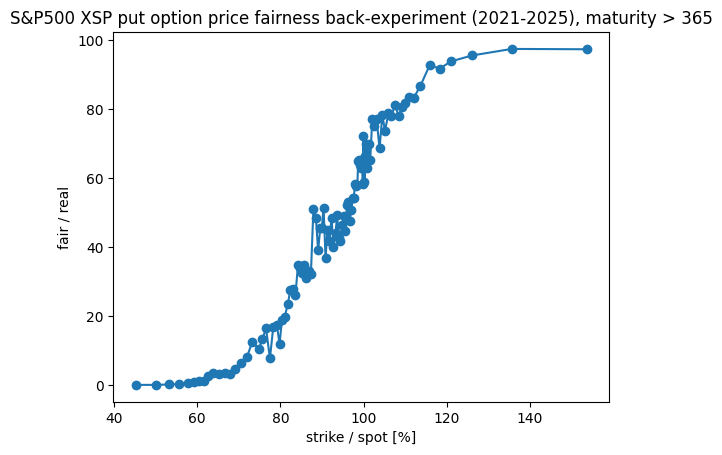

In [47]:
import matplotlib.pyplot as plt

plt.plot(grouped_avg["strike_pct"], grouped_avg["fair_pct"], marker='o')
plt.xlabel("strike / spot [%]")
plt.ylabel("fair / real")
plt.title(f"S&P500 XSP put option price fairness back-experiment (2021-2025), maturity > 365")
plt.show()
